In [33]:
import numpy as np
import healpy as hp
import pymaster as nmt
import matplotlib.pyplot as plt

# -----------------------------
# Survey & instrument parameters
# -----------------------------
D = 13.5                 # dish diameter [m]
t_obs = 4000 * 3600      # total observing time [s]
delta_nu = 1e6           # channel width [Hz]
N_dish = 64
T_sys = 20.0             # system temperature [K]

f_sky = 0.13221359252929688 #from mask.mean()
Omega_survey = 4 * np.pi * f_sky   # [sr]

nside=256
npix=hp.nside2npix(nside)
nu=np.arange(544,1088,step=10)
nfreqs=len(nu)-1
lmax=3*nside -1

bin_width=10
b = nmt.NmtBin.from_lmax_linear(lmax, bin_width)
n_bins = b.get_n_bands()
leff = b.get_effective_ells()

# -----------------------------
# Pixel solid angle (frequency dependent)
# -----------------------------
c = 3e8
theta_fwhm = 1.22 * c / (nu * D)          # [rad]
sigma_b = theta_fwhm / np.sqrt(8*np.log(2))
Omega_pix = 2 * np.pi * sigma_b**2        # [sr]


# -----------------------------
# Time per pixel
# -----------------------------
t_pix = t_obs * N_dish * Omega_pix / Omega_survey


sigma_N = T_sys / np.sqrt(2 * t_pix * delta_nu)  # [K]

# -----------------------------
# White noise angular power spectrum
# N_ell = sigma^2 * Omega_pix = sigma^2 * 4pi / N_pix
# -----------------------------
N_ell = sigma_N**2 * Omega_pix                   # [K^2 sr]



N_ell_binned = np.repeat(N_ell[:, None], len(leff), axis=1)
N_nu, N_bin = N_ell_binned.shape

# Noise covariance: (nu, nu', bin)
Cvvb = np.zeros((N_nu, N_nu, N_bin))

for b in range(N_bin):
    Cvvb[:, :, b] = np.diag(N_ell_binned[:, b])

# Shape: (N_nu, N_ell_bins)
print("Noise power spectrum shape:", Cvvb.shape)


Noise power spectrum shape: (55, 55, 76)


In [46]:
C_bvv = np.transpose(Cvvb, (2, 0, 1))
C_bvv.shape

(76, 55, 55)

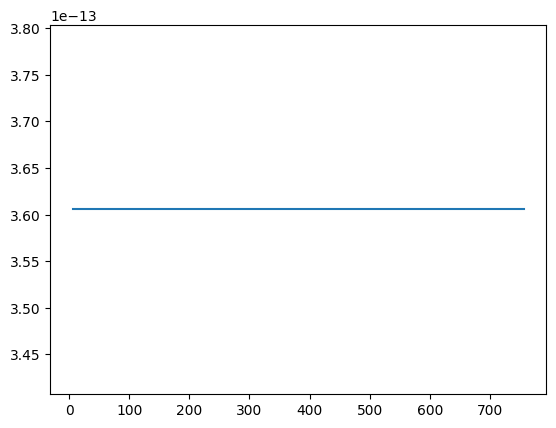

In [34]:
plt.plot(leff, Cvvb[20,20,:])
# plt.yscale('log')

In [35]:
np.linalg.eigvalsh(Cvvb[:, :, 1])

array([3.60556641e-13, 3.60556641e-13, 3.60556641e-13, 3.60556641e-13,
       3.60556641e-13, 3.60556641e-13, 3.60556641e-13, 3.60556641e-13,
       3.60556641e-13, 3.60556641e-13, 3.60556641e-13, 3.60556641e-13,
       3.60556641e-13, 3.60556641e-13, 3.60556641e-13, 3.60556641e-13,
       3.60556641e-13, 3.60556641e-13, 3.60556641e-13, 3.60556641e-13,
       3.60556641e-13, 3.60556641e-13, 3.60556641e-13, 3.60556641e-13,
       3.60556641e-13, 3.60556641e-13, 3.60556641e-13, 3.60556641e-13,
       3.60556641e-13, 3.60556641e-13, 3.60556641e-13, 3.60556641e-13,
       3.60556641e-13, 3.60556641e-13, 3.60556641e-13, 3.60556641e-13,
       3.60556641e-13, 3.60556641e-13, 3.60556641e-13, 3.60556641e-13,
       3.60556641e-13, 3.60556641e-13, 3.60556641e-13, 3.60556641e-13,
       3.60556641e-13, 3.60556641e-13, 3.60556641e-13, 3.60556641e-13,
       3.60556641e-13, 3.60556641e-13, 3.60556641e-13, 3.60556641e-13,
       3.60556641e-13, 3.60556641e-13, 3.60556641e-13])

In [48]:
np.save('noise_cov.npy', C_bvv)